# Homework 3: Survival Analysis and CLV Prediction
**Objective:** Evaluate churn risk of telecommunication subscribers using Accelerated Failure Time (AFT) models and calculate Customer Lifetime Value (CLV) incorporating survival probabilities.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading and Preprocessing
Load the dataset, drop the ID column, and encode categorical variables using dummy encoding.

In [17]:
df = pd.read_csv('Data/telco.csv') 

df_model = df.drop('ID', axis=1)

df_model['churn'] = df_model['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

categorical_cols = ['region', 'marital', 'ed', 'retire', 'gender', 'voice', 'internet', 'forward', 'custcat']

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

df_encoded.head()

,tenure,age,address,income,churn,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,retire_Yes,gender_Male,voice_Yes,internet_Yes,forward_Yes,custcat_E-service,custcat_Plus service,custcat_Total service
0,13,44,9,64,1,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,11,33,7,136,1,False,True,False,False,False,True,False,False,True,True,False,True,False,False,True
2,68,52,24,116,0,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False
3,33,33,12,33,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False
4,23,30,9,30,0,True,False,False,True,False,False,False,False,True,False,False,True,False,True,False


### 2. Building AFT Models & Comparison
We will build AFT models using Weibull, Log-Normal, and Log-Logistic distributions and compare their Akaike Information Criterion (AIC) to find the best fit.

In [18]:
weibull_aft = WeibullAFTFitter()
lognorm_aft = LogNormalAFTFitter()
loglog_aft = LogLogisticAFTFitter()

weibull_aft.fit(df_encoded, duration_col='tenure', event_col='churn')
lognorm_aft.fit(df_encoded, duration_col='tenure', event_col='churn')
loglog_aft.fit(df_encoded, duration_col='tenure', event_col='churn')

print("Weibull AIC:", weibull_aft.AIC_)
print("Log-Normal AIC:", lognorm_aft.AIC_)
print("Log-Logistic AIC:", loglog_aft.AIC_)

final_model = lognorm_aft

Weibull AIC: 2964.3432480838806
Log-Normal AIC: 2954.024010251712
Log-Logistic AIC: 2956.2085614433336


### 3. Visualizing Survival Curves fro all three distributions.

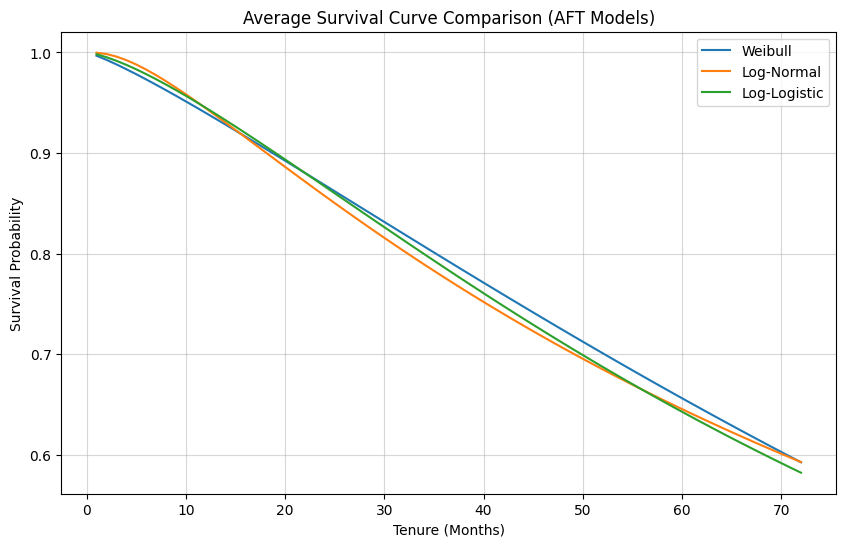

In [19]:
plt.figure(figsize=(10, 6))

mean_df = df_encoded.drop(['tenure', 'churn'], axis=1).mean().to_frame().T

surv_weibull = weibull_aft.predict_survival_function(mean_df)
surv_lognorm = lognorm_aft.predict_survival_function(mean_df)
surv_loglog = loglog_aft.predict_survival_function(mean_df)

plt.plot(surv_weibull.index, surv_weibull.iloc[:, 0], label='Weibull')
plt.plot(surv_lognorm.index, surv_lognorm.iloc[:, 0], label='Log-Normal')
plt.plot(surv_loglog.index, surv_loglog.iloc[:, 0], label='Log-Logistic')

plt.title('Average Survival Curve Comparison (AFT Models)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### 4. Final Model with Significant Features
We refine our Log-Normal model by keeping only the statistically significant features (p-value < 0.05).

In [20]:
summary_df = final_model.summary

significant_vars = summary_df[summary_df['p'] < 0.05].index.get_level_values(1).unique().tolist()

significant_vars = [var for var in significant_vars if var not in ['_intercept', 'Intercept', 'tenure', 'churn']]
print("Significant features kept:", significant_vars)

df_final = df_encoded[['tenure', 'churn'] + significant_vars]

final_model = LogNormalAFTFitter()
final_model.fit(df_final, duration_col='tenure', event_col='churn')

Significant features kept: ['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'internet_Yes', 'marital_Unmarried', 'voice_Yes']


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>

---
## 5. Customer Lifetime Value (CLV)

Using the final Log-Normal AFT model, we compute CLV per customer as the **expected discounted revenue** over a 24-month horizon:

$$CLV_i = \sum_{t=1}^{T} r \cdot S_i(t) \cdot (1+d)^{-t/12}$$

where $r = 50$ USD is the assumed monthly revenue per subscriber, $S_i(t)$ is the individual survival probability at month $t$, and $d = 0.10$ is the annual discount rate.

In [ ]:
monthly_revenue = 50      # USD per month per subscriber
annual_discount = 0.10    # 10% annual discount rate
time_horizon    = 24      # months

times = np.arange(1, time_horizon + 1)
discount_factors = np.array([(1 + annual_discount) ** (-t / 12) for t in times])

X_final = df_final.drop(['tenure', 'churn'], axis=1)

surv_matrix = final_model.predict_survival_function(X_final, times=times)

clv_per_customer = (surv_matrix.T * (monthly_revenue * discount_factors)).T.sum(axis=0)

df_results = df_model.copy().reset_index(drop=True)
df_results['CLV'] = clv_per_customer.values

print(f"CLV Summary:")
print(df_results['CLV'].describe().round(2))

CLV Summary:
count    1000.00
mean      971.20
std       121.94
min       351.06
25%       906.56
50%      1013.14
75%      1067.04
max      1088.19
Name: CLV, dtype: float64


### 5.1 CLV by Customer Category

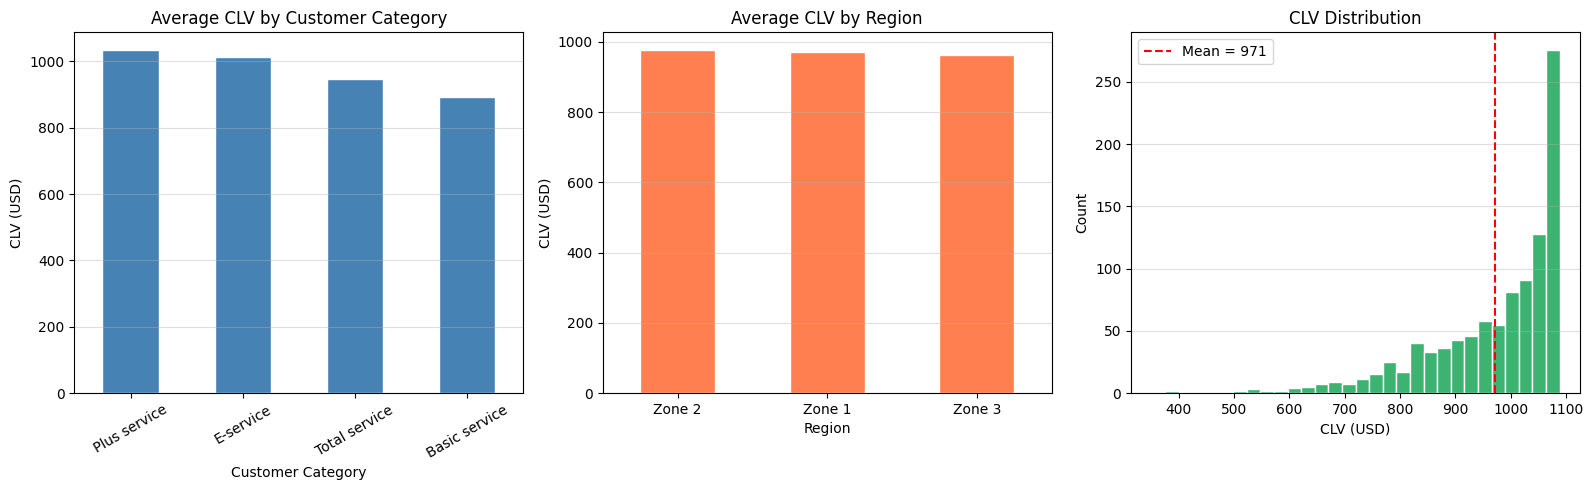

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

clv_by_cat = df_results.groupby('custcat')['CLV'].mean().sort_values(ascending=False)
clv_by_cat.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average CLV by Customer Category')
axes[0].set_xlabel('Customer Category')
axes[0].set_ylabel('CLV (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.4)

clv_by_region = df_results.groupby('region')['CLV'].mean().sort_values(ascending=False)
clv_by_region.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average CLV by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('CLV (USD)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.4)

axes[2].hist(df_results['CLV'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].axvline(df_results['CLV'].mean(), color='red', linestyle='--', label=f'Mean = {df_results["CLV"].mean():.0f}')
axes[2].set_title('CLV Distribution')
axes[2].set_xlabel('CLV (USD)')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 5.2 CLV by Marital Status & Internet Service

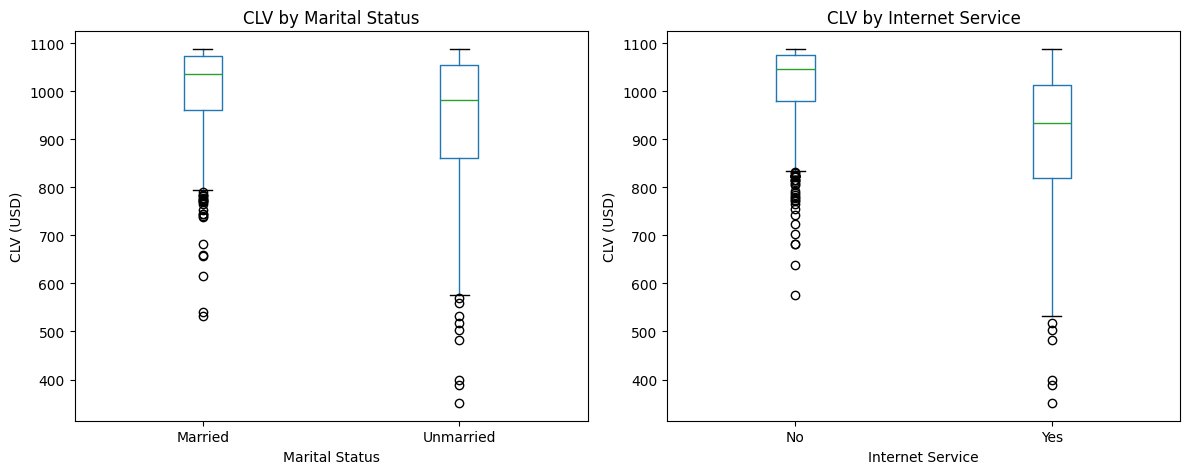


CLV by Customer Category (detailed):
                  mean   median  count
custcat                               
Basic service   892.27   912.37    266
E-service      1012.91  1039.84    217
Plus service   1035.50  1057.70    281
Total service   945.27   973.61    236


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_results.boxplot(column='CLV', by='marital', ax=axes[0], grid=False)
axes[0].set_title('CLV by Marital Status')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('CLV (USD)')
plt.suptitle('')  

df_results.boxplot(column='CLV', by='internet', ax=axes[1], grid=False)
axes[1].set_title('CLV by Internet Service')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('CLV (USD)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nCLV by Customer Category (detailed):")
print(df_results.groupby('custcat')['CLV'].agg(['mean','median','count']).round(2))

### 5.3 At-Risk Subscribers & Retention Budget

In [ ]:
surv_at_12 = final_model.predict_survival_function(X_final, times=[12]).iloc[0]
df_results['surv_12m'] = surv_at_12.values

df_results['at_risk'] = df_results['surv_12m'] < 0.5
n_at_risk = df_results['at_risk'].sum()

print(f"Subscribers at risk within 1 year (S(12) < 0.5): {n_at_risk}")
print(f"At-risk rate: {n_at_risk / len(df_results):.1%}")

clv_at_risk = df_results.loc[df_results['at_risk'], 'CLV']
total_value_at_risk = clv_at_risk.sum()

print(f"\nTotal CLV at risk: ${total_value_at_risk:,.0f}")
print(f"Average CLV of at-risk subscriber: ${clv_at_risk.mean():,.0f}")

retention_budget_low  = total_value_at_risk * 0.10
retention_budget_high = total_value_at_risk * 0.20
print(f"\nSuggested annual retention budget: ${retention_budget_low:,.0f} – ${retention_budget_high:,.0f}")
print(f"(10–20% of total CLV at risk, per industry convention)")

Subscribers at risk within 1 year (S(12) < 0.5): 14
At-risk rate: 1.4%

Total CLV at risk: $7,136
Average CLV of at-risk subscriber: $510

Suggested annual retention budget: $714 – $1,427
(10–20% of total CLV at risk, per industry convention)


### 5.4 Most Valuable Segments
We define **value** as: high CLV AND low churn risk (high 12-month survival). These are customers worth retaining *and* least likely to leave on their own.

In [ ]:
df_results['clv_quartile'] = pd.qcut(df_results['CLV'], q=4, labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])

segment_summary = df_results.groupby('clv_quartile').agg(
    n_customers=('CLV', 'count'),
    avg_clv=('CLV', 'mean'),
    avg_surv_12m=('surv_12m', 'mean'),
    pct_at_risk=('at_risk', 'mean')
).round(3)
print(segment_summary)

top_segment = df_results[
    (df_results['clv_quartile'] == 'Q4 (High)') & (~df_results['at_risk'])
]
print(f"\nHigh-value, low-risk customers: {len(top_segment)}")
print(f"Their average CLV: ${top_segment['CLV'].mean():,.0f}")
if 'custcat' in top_segment.columns:
    print("\nDistribution by category:")
    print(top_segment['custcat'].value_counts())

              n_customers   avg_clv  avg_surv_12m  pct_at_risk
clv_quartile                                                  
Q1 (Low)              250   795.398         0.711        0.056
Q2                    250   966.552         0.890        0.000
Q3                    250  1042.954         0.963        0.000
Q4 (High)             250  1079.906         0.994        0.000

High-value, low-risk customers: 250
Their average CLV: $1,080

Distribution by category:
custcat
Plus service     123
E-service         66
Total service     42
Basic service     19
Name: count, dtype: int64
